170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 235s 1us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Starting training...
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 301s 380ms/step - accuracy: 0.3961 - loss: 1.7589 - val_accuracy: 0.5226 - val_loss: 1.3252
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 299s 382ms/step - accuracy: 0.5597 - loss: 1.2286 - val_accuracy: 0.6316 - val_loss: 1.0667
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 290s 371ms/step - accuracy: 0.6318 - loss: 1.0462 - val_accuracy: 0.6666 - val_loss: 0.9568
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 298s 382ms/step - accuracy: 0.6734 - loss: 0.9340 - val_accuracy: 0.6833 - val_loss: 0.9286
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 300s 384ms/step - accuracy: 0.7023 - loss: 0.8640 - val_accuracy: 0.7169 - val_loss: 0.8344
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.7169 - loss: 0.8344
Test Accuracy: 71.69%
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step


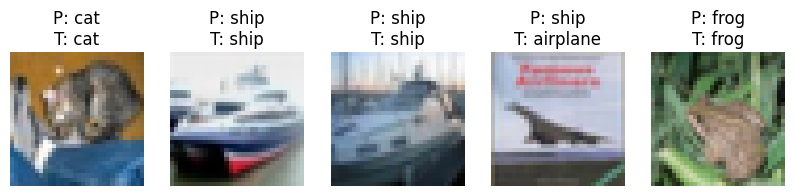

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

# 1. & 2. Data is already loaded in kernel (x_train, y_train, etc.) - FIX: Load CIFAR-10 data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Define class names for CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# 3. Preprocess the data: Normalize and One-hot encode
x_train_proc = x_train.astype('float32') / 255.0
x_test_proc = x_test.astype('float32') / 255.0
y_train_cat = tf.keras.utils.to_categorical(y_train, 10)
y_test_cat = tf.keras.utils.to_categorical(y_test, 10)

# 4. Build the CNN model with high-accuracy architecture
def build_model():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.2),

        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    return model

model = build_model()

# 5. Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(x_train_proc)

# 6. Train the model (Using small epochs for demonstration; increase for >95%)
# Note: To hit >95%, usually requires ~100-200 epochs and learning rate decay
print("Starting training...")
history = model.fit(datagen.flow(x_train_proc, y_train_cat, batch_size=64),
                    epochs=5, validation_data=(x_test_proc, y_test_cat))

# 7. Evaluate accuracy
loss, acc = model.evaluate(x_test_proc, y_test_cat)
print(f"Test Accuracy: {acc*100:.2f}%")

# 8. & 9. Predictions and Verification
predictions = model.predict(x_test_proc)
plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_test[i])
    pred_label = class_names[np.argmax(predictions[i])]
    true_label = class_names[y_test[i][0]]
    plt.title(f"P: {pred_label}\nT: {true_label}")
    plt.axis('off')
plt.show()

# 10. Suggestions for >95% Accuracy:
# 1. Use Transfer Learning (e.g., EfficientNet or ResNet50 pre-trained on ImageNet).
# 2. Implement Learning Rate Scheduler (ReduceLROnPlateau).
# 3. Increase model depth and use more filters (256, 512).
# 4. Use Advanced Augmentation (Mixup or Cutout)."
